# GEEMAP built-in palettes and NDVI

## Introduction
### Purpose
This post is an exploration of the built-in palettes that come with ```GEEMAP```. 

```GEEMAP``` is a  Python package for interactive geospatial analysis and visualization with Google Earth Engine.

```GEEPMAP``` uses ```Cartopy``` which uses ```matplotlib```, and so you get all the ```matplotlib``` color maps for free, but there a couple of extra ones thrown in.  These support two of the Spectral Indices that have been defined to allow analysis of LANDSAT images (or, indeed, any sort of multispectral remote imaging).

To be more focussed, I thought I would look at the countryside around my home turf.  This article goes into some of the issues of visualizing sensor data.

### NDVI or Normalized difference vegetation index

As Wikipedia says:

      The normalized difference vegetation index (NDVI) is a widely used metric for quantifying the health and density of vegetation using sensor data. It is calculated from spectrometric data at two specific bands: red and near-infrared. The spectrometric data is usually sourced from remote sensors, such as satellites.The metric is popular in industry because of its accuracy. It has a high correlation with the true state of vegetation on the ground.

      The NDVI is calculated from these individual measurements as follows:
      
        NDVI =  (NIR - RED) / (NIR + RED)

      where Red and NIR stand for the spectral reflectance measurements acquired in the red (visible) and near-infrared regions

--------------------

## Implementation
### Set up environment
Import packages and Jupyter extensions

```lab_black``` auto-formats Python code

```watermark``` produces reproducability information

In [135]:
%load_ext lab_black

The lab_black extension is already loaded. To reload it, use:
  %reload_ext lab_black


In [136]:
%load_ext watermark

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark


### Imports

In [137]:
import ee
import geemap
import geemap.foliumap as gf
import geemap.colormaps as cm

from matplotlib.colors import LinearSegmentedColormap

## Analysis of Palettes

### List the extra palettes

In order to list the ```extra``` palettes defined for us, I look at the difference between the normal colormap list, and the list with extras added.  I could have used Python sets to get this difference, but this works.

We get three extra palettes: 

- one for Digital Elevation Models (dem):
- one for Normalized difference vegetation index (ndvi),
- one for Normalized difference water index (ndwi)

In [138]:
[
    p
    for p in geemap.colormaps.list_colormaps(add_extra=True)
    if p not in geemap.colormaps.list_colormaps(add_extra=False)
]

['dem', 'ndvi', 'ndwi']

We now examine the data associated with a palette.  It is a tuple of CSS-style Hex color strings.

In [139]:
cm.palettes.ndvi

('FFFFFF',
 'CE7E45',
 'DF923D',
 'F1B555',
 'FCD163',
 '99B718',
 '74A901',
 '66A000',
 '529400',
 '3E8601',
 '207401',
 '056201',
 '004C00',
 '023B01',
 '012E01',
 '011D01',
 '011301')

### Build colormaps

In order to visualize these palettes, I build a ```matplotlib``` colormap.  To do this, I need a function to convert the Hex string CSS colors to normalised RGB tuples

In [140]:
def hex_to_rgb(color: str) -> tuple[float, float, float]:
    """
    hex_to_rgb: convert CSS-style color specification to RGB tuple

    Parameters:
    color - string of form HHHHHH or #HHHHHH (H = hex digit)

    Returns:
    tuple(float, float, float) normalised to 0.0<->1.0
    """
    col = color.replace("#", "")
    r = int(col[0:2], 16) / 255.0
    g = int(col[2:4], 16) / 255.0
    b = int(col[4:6], 16) / 255.0
    return (r, g, b)


# end hxe_to_rgb

print(hex_to_rgb("FF0000"))  # -> (1,0,0)
print(hex_to_rgb("00FF00"))  # -> (0,1,0)
print(hex_to_rgb("0000FF"))  # -> (0,0,1)

(1.0, 0.0, 0.0)
(0.0, 1.0, 0.0)
(0.0, 0.0, 1.0)


### Show palettes as colormaps

We ask for 20 different colors in the visualization

#### NDVI

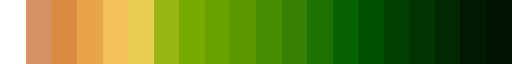

In [141]:
# convert NDVI palette (hex color string) to a list of RGB tuples
ndvi_colors = [hex_to_rgb(hex_color) for hex_color in cm.palettes.ndvi]

# create color map from list of RGB color tuples
cmap_ndvi = LinearSegmentedColormap.from_list("ndvi", ndvi_colors, N=20)

# display color map
cmap_ndvi

#### NDWI

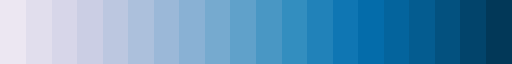

In [142]:
# convert NDWI palette (hex color string) to a list of RGB tuples
ndwi_colors = [hex_to_rgb(hex_color) for hex_color in cm.palettes.ndwi]

# create color map from list of RGB color tuples
ndwi_ndvi = LinearSegmentedColormap.from_list("ndwi", ndwi_colors, N=20)

# display color map
ndwi_ndvi

### Discussion

The NDVI color map ranges from Brown to very dark Green, as the vegetation cover increases.  My taste says that the end (maximum vegetation) Green is a little too dark.

The NDWI is an index used for water-body detection.  Seeing that I live about one Kilometre from the Pacific Ocean, I need an index like this

----------------

## Run an Example

### Data Selection

I elected to use the USGS Landsat 8, Collection 2, Tier 1, TOA Reflectance.

An explanation of some of the terms (mostly summarised from  [https://www.usgs.gov/landsat-missions/] pages)

- Top-of-atmosphere reflectance (or TOA reflectance) is the reflectance measured by a space-based sensor flying higher than the earth's atmosphere. These reflectance values will include contributions from clouds and atmospheric aerosols and gases

- Landsat Collection 2 represents the state-of-art (as opposed to LANDSAT Collection 1). A primary characteristic of Collection 2 is the substantial improvement in the absolute geolocation accuracy of the global ground reference dataset used in the Landsat Level-1 processing flow.

- The USGS produces data in 3 tiers (categories) for each satellite: Tier 1 (T1) - Data that meets geometric and radiometric quality requirements.

For my purposes, I am not realy fussed about very high accuracy, or the effects of the atmosphere in distorting the measurements: I just want something easy to access, to compute a NDVI score.  If I was a Wheat Futures Trader, trying to accurately estimate the future grain production of Canada (say), I would probably use the best data available (which in this case, might be Surface Reflectance values, which remove atmospheric distortions).

### Setup GEEMAP and Google Earth Engine

In [143]:
ee.Authenticate()

True

In [144]:
ee.Initialize()

Specify the Google Earth Engine image collection we want to use

In [145]:
toa_collection_name = "LANDSAT/LC08/C02/T1_TOA"

#### Specify image subsets

Filter out all but images from the last 18 months, to avoid any droughts in the past

In [146]:
start_date = "2024-01-01"
end_date = "2025-06-30"

l8 = ee.ImageCollection(toa_collection_name).filterDate(start_date, end_date)

Show how many images in this date range

In [147]:
print(
    f"{l8.size().getInfo()} images in period {start_date} to {end_date} days of LANDSAT"
)

238473 images in period 2024-01-01 to 2025-06-30 days of LANDSAT


Now filter out images that don't cover my home, and show the new count

In [148]:
# get a point close to home
home = ee.Geometry.Point(153, -26.5)

# only use images that cover home
f3 = l8.filter(ee.Filter.bounds(home))

# show count of images
print(f"{f3.size().getInfo()} images covering home")

58 images covering home


#### Cloud processing

I know from experiance that some (if not all) of any random image will have clouds obscuring some of the countryside.

We address this by specifying we want the ```median``` pixel out of the pixels that cover a given location.  An image with cloud cover will not move the median much.

In [149]:
# get the median value for each pixel (hopefully means clouds dont show)
best = f3.median()

Examine the bands for the image we have created.  It is as expected

In [150]:
# show metadata relating to best image
print(best.bandNames().getInfo())

['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'QA_PIXEL', 'QA_RADSAT', 'SAA', 'SZA', 'VAA', 'VZA']


### Visualisation

#### Show true color

We adjust the ```gamma``` value to lighten the image a little

In [151]:
# set up for true color image
# gamma value will lighten image

visParams = {
    "bands": ["B4", "B3", "B2"],
    "min": 0,
    "max": 0.4,
    "gamma": 1.5,
}

Setup a default GEEMAP map that covers my home, and add the RGB True Color image to it as an overlay

In [152]:
map = gf.Map()
map.set_center(153.0890232, -26.5282752, 14)
map.addLayer(best, visParams, "Median")

In [153]:
map

## NDVI Calculation

Computing the NDVI is easy, the tricky part is setting the min / max parameters so the color map looks OK

Guidence from the Bureau of Meteorology:

    NDVI in Australia typically ranges from 0.1 up to 0.7, with higher values associated with greater density and greenness of the plant canopy. NDVI decreases as leaves come under water stress, become diseased or die. Bare soil and snow values are close to zero, while water bodies have negative values.
    [https://www.bom.gov.au/climate/austmaps/about-ndvi-maps.shtml]


In [154]:
# Calculate normalized difference vegetation index: (NIR - Red) / (NIR + Red).
nir_band = "B5"
red_band = "B4"
ndvi = best.normalizedDifference([nir_band, red_band])

# Display NDVI result on the map.
m = gf.Map()
m.set_center(153.0890232, -26.5282752, 14)
m.add_layer(
    ndvi,
    {
        "min": 0.0,
        "max": 0.7,
        "palette": "ndvi",
    },
    "NDVI",
)

Show results

In [155]:
m

### Assesment

This is quiet a good visualisation. I can see the un-vegetated areas of the Industrial Estate behind Coolum Beach, the lines of tree along fence lines, and even where power lines that have been cleared of most vegetation.  However, I feel that it is hard to get much detail from the dark green area.

So next I decided to ise a color map of my own selection, namely the ```matplotlib``` Red to Yellow to Green ramp.  In the display of the color map below, note that there is no ```under``` or ```over``` colors specified, which show the color to display for pixel values outside our nominated range.  This will bite us, as can be seen soon.

#### Show new colormap

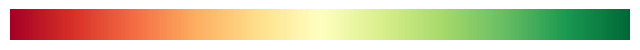

In [156]:
cm.plot_colormap("RdYlGn")

#### Map new Colormap

We use the same data range as before.

In [157]:
# Display NDVI result on the map.
m = gf.Map()
m.set_center(153.0890232, -26.5282752, 14)
m.add_layer(
    ndvi,
    {
        "min": 0,
        "max": 0.7,
        "palette": "RdYlGn",
    },
    "NDVI",
)
m

#### Assessment

I think this a better color map: you can see more detail (e.g. you can make out tree-lined narrow roads that you couldn't make out in the original ```ndvi``` palette.  The only trouble is the sea of blood to the east :)

This is because when you set the ```min``` and ```max``` in ```vis_params```, ```GEEMAP```  will automatically display values below ```min``` in the lowest color of the palette and values above ```max``` in the highest color.  It is opposed to the behaviour for the ```ndvi``` palette, where white is used for pixel value below the minimum specified.  So all the ocean pixels that were white, are now deep red.

What to do?  There are two ways to solve this.  The first is by using a waterbody mask

There is an index specified that allows water body detection, the Normalized Difference Water Index (NDWI).


## NDWI

To summarise from EOS Data Analytics:

The NDWI is calculated using the GREEN-NIR (visible green and near-infrared) combination, which allows it to detect subtle changes in water content of the water bodies

The visible green wavelengths maximize the typical reflectance of the water surface. The near-infrared wavelengths maximize the high reflectance of terrestrial vegetation and soil features, while minimizing the low reflectance of water features.

The result of the NDWI equation is positive values for water features and negative ones (or zero) for soil and terrestrial vegetation.
Values of water bodies are larger than 0.5. Vegetation has much smaller values, which results in distinguishing vegetation from water bodies easier. Built-up features have positive values between 0 and 0.2.

The NDWI values correspond to the following ranges:
- 0.2 <–> 1 – Water surface,
- 0.0 <–> 0,2 – Flooding, humidity,
- -0.3 <–> 0.0 – Moderate drought, non-aqueous surfaces,
- -1 <–> -0.3 – Drought, non-aqueous surfaces

[https://eos.com/make-an-analysis/ndwi/]

In [158]:
# Create an NDWI image, define visualization parameters and display.
ndwi = best.normalizedDifference(["B3", "B5"])

ndwi_viz = {"min": -0.2, "max": 1, "palette": "ndwi"}

#### Show NDWI on map

In [159]:
# Display NDWI result on the map.
m = gf.Map()
m.set_center(153.0890232, -26.5282752, 10)
m.add_layer(
    ndwi,
    ndwi_viz,
    "NDWI",
)
m

This exactly what we want.  We can use this NDWI image to create a mask that prevent NDVI value for the ocean, lake, etc to be shown.

The NDWI threshold value was chosen by trial and error

#### Create mask, and masked image

In [160]:
water_threshold = 0.25

ndwi_masked = ndwi.updateMask(ndwi.gte(water_threshold))
ndvi_masked = ndvi.updateMask(ndwi.lte(water_threshold))

#### Display masked NDVI image

We could mosaic in the NDWI image, but are only concerned with land: the basemap is fine for the ocean.  So we just display the masked NDVI image

In [161]:
# Display NDWI, NDVI combined result on the map.
m = gf.Map()
m.set_center(153.0890232, -26.5282752, 13)

m.add_layer(
    ndvi_masked,
    {
        "min": 0,
        "max": 0.7,
        "palette": "RdYlGn",
    },
    "NDVI",
)

In [162]:
m

## Handcrafted palette

The second approach is to mimic the ```under``` value of a ```matplotlib``` color map.  We get the list of Hex strings corresponding to a chosen colormap, add white to the front (White = FFFFFF), and use that list of colors in a visualization parameter.

Get the colors used in the RdYlGn colormap

In [163]:
colors = cm.get_palette(
    cmap_name="RdYlGn",
)
# show first 10 colors
print(colors[0:10])

['a50026', 'a70226', 'a90426', 'ab0626', 'ad0826', 'af0926', 'b10b26', 'b30d26', 'b50f26', 'b71126']


Append white to front

In [164]:
color_extd = [
    "ffffff",
] + colors

Show NDVI image, using extended palette to turn below-range pixels white.  If you look very carefully, there a few pixels that have an NDVI value right at the bottom edge of the valid range: they were Red, but are now White.  For my purposes, this is an acceptable distortion.  If we were really concerned, we could adjust the ```min``` value to show these pixels as Red.

In [165]:
# Display NDVI result on the map.
m = gf.Map()
m.set_center(153.0890232, -26.5282752, 14)
m.add_layer(
    ndvi,
    {
        "min": 0,
        "max": 0.7,
        "palette": color_extd,
    },
    "NDVI",
)
m

--------------------
## Conclusion

I am always surprised how easy it is to use Google Earth Engine to access LANDSAT datasets, and how easy ```GEEMAP``` make visualization.  Further, it is relatively easy to use different color maps to highlight aspects of an image

Of course, a little knowledge can be a dangerous thing, and a professional remote sensing person would have to right across the fine detail of how LANDSAT does its data corrections, and the best algorithms for a given  task (e.g. Normalized Difference Water Index vs Normalized Difference Moisture Index)


----------------------
## Reproducibilty

In [166]:
%watermark

Last updated: 2025-08-25T13:09:24.642609+10:00

Python implementation: CPython
Python version       : 3.12.7
IPython version      : 8.29.0

Compiler    : MSC v.1941 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 170 Stepping 4, GenuineIntel
CPU cores   : 22
Architecture: 64bit



In [167]:
%watermark -co  -iv -v -h

Python implementation: CPython
Python version       : 3.12.7
IPython version      : 8.29.0

conda environment: geospatial

Hostname: INSPIRON16

geemap    : 0.35.1
ee        : 1.3.1
matplotlib: 3.8.4

